In [60]:
# Code Block 1

import os
from pathlib import Path

#this is the path to my dataset stored in a folder
DATASET_DIR = Path("data/raw/hela_draw_images_Annotated by Adonis")

print("Data directory: ", DATASET_DIR)
print("Folders inside the data directory: ", os.listdir(DATASET_DIR))

Data directory:  data/raw/hela_draw_images_Annotated by Adonis
Folders inside the data directory:  ['MD-Experiment-000533_hela15', 'MD-Experiment-000533_hela4', 'MD-Experiment-000533_hela11', 'MD-Experiment-000533_hela1']


In [62]:
# Code Block 2

for root, dirs, files in os.walk(DATASET_DIR):
    for file in files:
        if file == ".DS_Store":
            os.remove(os.path.join(root, file))

print("Hidden files removed")

Hidden files removed


In [65]:
# Code Block 3

from PIL import Image

converted = 0

for root, dirs, files in os.walk(DATASET_DIR):
    for file in files:
        if file.lower().endswith(".tif"):
            tif_path = os.path.join(root, file)
            jpg_path = os.path.join(root, file.replace(".tif", ".jpg"))

            img = Image.open(tif_path)
            img.convert("RGB").save(jpg_path, "JPEG")

            converted += 1

print("Converted", converted, "images to JPG")

Converted 1440 images to JPG


In [67]:
# Code Block 4

label_counts = {}

for folder in os.listdir(DATASET_DIR):
    folder_path = DATASET_DIR / folder

    if folder_path.is_dir():
        images = [
            f for f in os.listdir(folder_path)
            if f.lower().endswith((".jpg",".jpeg",".png"))
        ]
        label_counts[folder] = len(images)

print(label_counts)

{'MD-Experiment-000533_hela15': 480, 'MD-Experiment-000533_hela4': 480, 'MD-Experiment-000533_hela11': 480, 'MD-Experiment-000533_hela1': 480}


In [69]:
# Code Block 5
"""checking the imported libraries, also checking if the dataset path 
exists and the structure is correct"""

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("Exists:", DATASET_DIR.exists())
print("Subfolders:", os.listdir(DATASET_DIR))

Exists: True
Subfolders: ['MD-Experiment-000533_hela15', 'MD-Experiment-000533_hela4', 'MD-Experiment-000533_hela11', 'MD-Experiment-000533_hela1']


In [71]:
# Code Block 6
"""Loading dataset and splitting it into train, validation and test"""

image_size = (224, 224)
batch_size = 32

dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    image_size=image_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42
)

class_names = dataset.class_names
print("Classes:", class_names)

dataset = dataset.shuffle(buffer_size=1000, seed=42)

dataset_size = dataset.cardinality().numpy()

train_size = int(0.7 * dataset_size)
val_size = int(0.2 * dataset_size)

train_ds = dataset.take(train_size)
validation_ds = dataset.skip(train_size).take(val_size)
test_ds = dataset.skip(train_size + val_size)

print("Train batches:", train_size)
print("Validation batches:", val_size)
print("Test batches:", dataset_size - train_size - val_size)

Found 1920 files belonging to 4 classes.
Classes: ['MD-Experiment-000533_hela1', 'MD-Experiment-000533_hela11', 'MD-Experiment-000533_hela15', 'MD-Experiment-000533_hela4']
Train batches: 42
Validation batches: 12
Test batches: 6


In [73]:
# Code Block 7

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = []

for images, y in train_ds:
    labels.extend(y.numpy())

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

print("Class weights:", class_weights)

Class weights: {0: 1.0, 1: 1.0, 2: 1.05, 3: 0.9545454545454546}


2026-03-31 00:02:20.900822: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [75]:
# Code Block 8
for images, labels in train_ds.take(1):
    print("Labels in batch:", set(labels.numpy()))

Labels in batch: {0, 1, 2, 3}


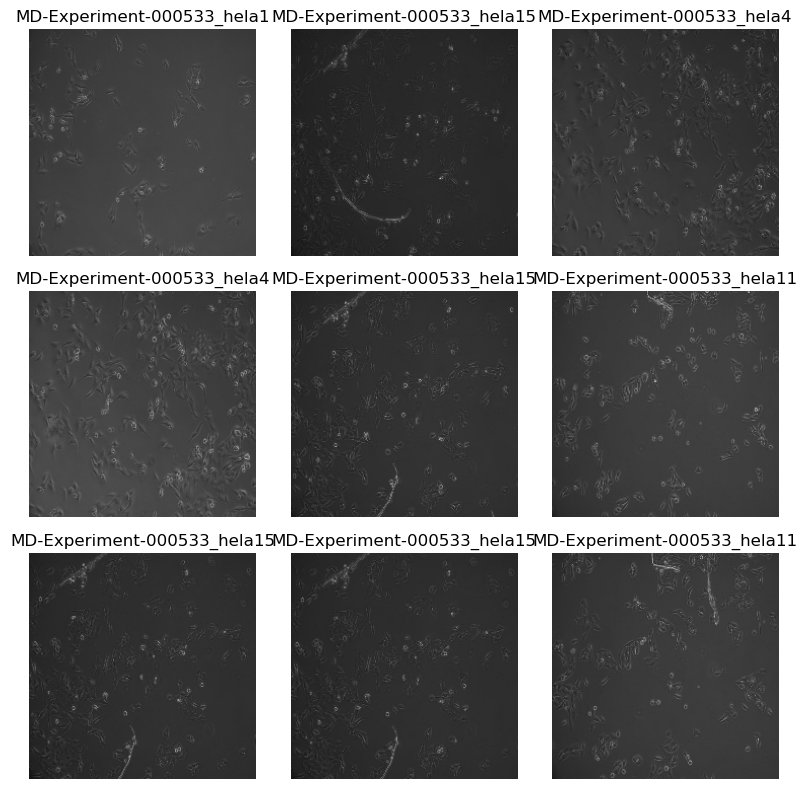

In [77]:
# Code Block 9

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [79]:
# Code Block 10

"""Normalization and prefetching, normalizing image pixel values
and optimizing data loading"""

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
validation_ds = validation_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Normalization completed")

Normalization completed


In [81]:
# Code Block 11

for images, labels in train_ds.take(1):
    print("Min:", images.numpy().min())
    print("Max:", images.numpy().max())

Min: 0.06086706
Max: 0.91732717


In [84]:
# Code Block 12

train_batches = train_ds.cardinality().numpy()
val_batches = validation_ds.cardinality().numpy()

print("Train batches:", train_batches)
print("Validation batches:", val_batches)

Train batches: 42
Validation batches: 12


In [86]:
# Code Block 13

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

print("Augmentation ready")

Augmentation ready


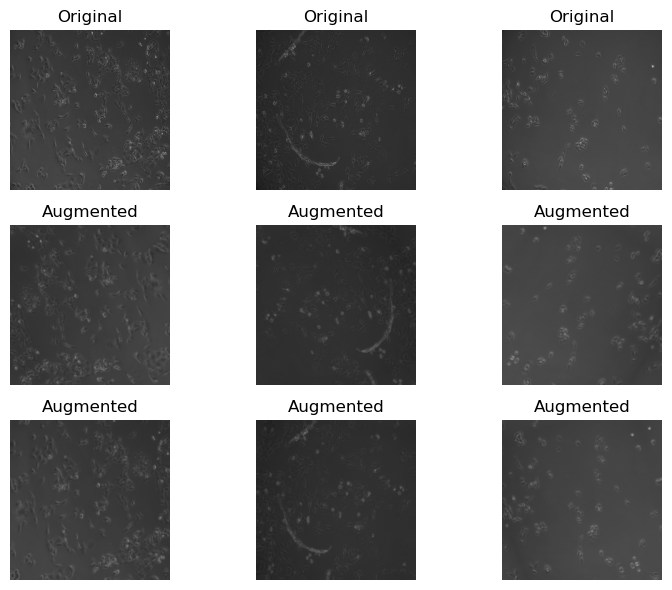

In [88]:
# Code Block 14

plt.figure(figsize=(8,6))

for images, labels in train_ds.take(1):
    sample_images = images[0:3]

    for i in range(3):
        plt.subplot(3,3,i+1)
        plt.imshow(sample_images[i].numpy())
        plt.title("Original")
        plt.axis("off")

        aug = data_augmentation(tf.expand_dims(sample_images[i], axis=0))
        plt.subplot(3,3,i+4)
        plt.imshow(aug[0].numpy())
        plt.title("Augmented")
        plt.axis("off")

        aug2 = data_augmentation(tf.expand_dims(sample_images[i], axis=0))
        plt.subplot(3,3,i+7)
        plt.imshow(aug2[0].numpy())
        plt.title("Augmented")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [90]:
# Code Block 15

num_classes = len(class_names)

model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,276 (462.02 KB)

 Trainable params: 118,276 (462.02 KB)

 Non-trainable params: 0 (0.00 B)

In [92]:
# Code Block 16

from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0001)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [54]:
# Code Block 17
"""Compile CNN"""

from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0001)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [94]:
# Code Block 18

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 23s 483ms/step - accuracy: 0.2711 - loss: 1.3826 - val_accuracy: 0.2526 - val_loss: 1.3809
Epoch 2/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 22s 483ms/step - accuracy: 0.2722 - loss: 1.3798 - val_accuracy: 0.2370 - val_loss: 1.3835
Epoch 3/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 22s 485ms/step - accuracy: 0.2563 - loss: 1.3857 - val_accuracy: 0.2448 - val_loss: 1.3807
Epoch 4/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 22s 490ms/step - accuracy: 0.2683 - loss: 1.3833 - val_accuracy: 0.2474 - val_loss: 1.3759
Epoch 5/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 23s 498ms/step - accuracy: 0.2708 - loss: 1.3797 - val_accuracy: 0.2656 - val_loss: 1.3676
Epoch 6/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 22s 487ms/step - accuracy: 0.2733 - loss: 1.3706 - val_accuracy: 0.4297 - val_loss: 1.3506
Epoch 7/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 22s 483ms/step - accuracy: 0.3287 - loss: 1.3587 - val_accuracy: 0.3490 - val_loss: 1.3533
Epoch 8/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 22s 485ms/step - accuracy: 0.3538 - loss: 1.3397 - val_accu

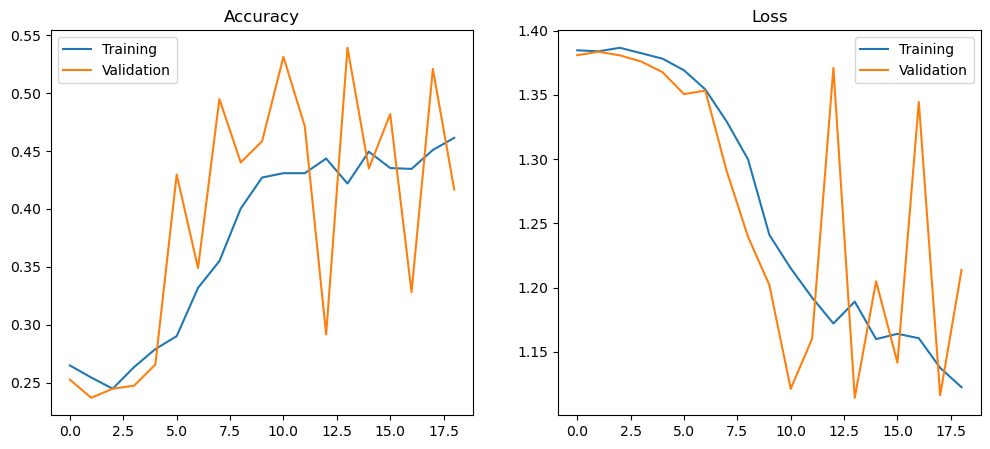

In [96]:
# Code Block 19

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.legend()
plt.title("Loss")

plt.show()

In [98]:
# Code Block 20
import numpy as np

y_true = []
y_predicted = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy().tolist())
    y_predicted.extend(predicted_classes.tolist())

print("Total true labels:", len(y_true))
print("Total predictions:", len(y_predicted))

print("Example true labels:", y_true[:10])
print("Example predictions:", y_predicted[:10])

Total true labels: 192
Total predictions: 192
Example true labels: [2, 1, 1, 1, 2, 0, 0, 3, 1, 3]
Example predictions: [2, 2, 3, 2, 2, 3, 2, 2, 3, 3]


<Figure size 800x600 with 0 Axes>

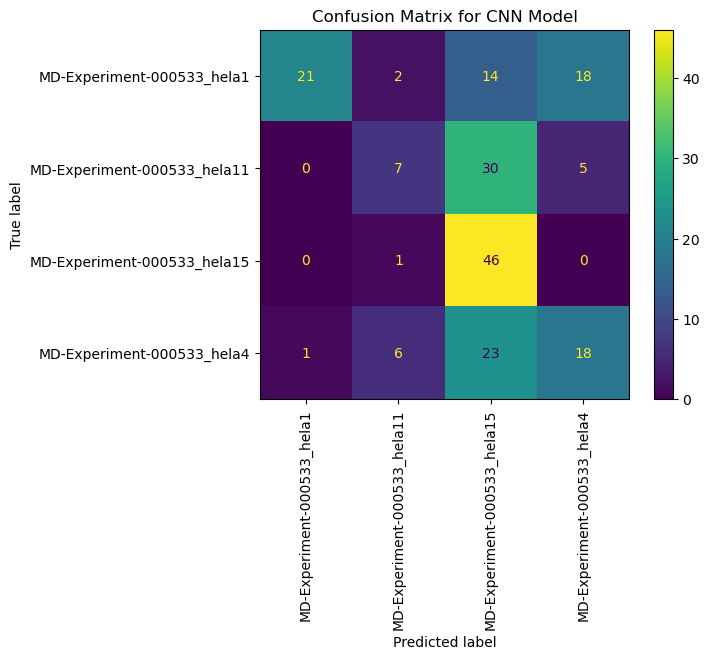

In [100]:
# Code Block 21

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = list(range(len(class_names)))

cm = confusion_matrix(
    y_true,
    y_predicted,
    labels=labels
)

plt.figure(figsize=(8,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(xticks_rotation=90, cmap="viridis")
plt.title("Confusion Matrix for CNN Model")

plt.show()

In [102]:
# Code Block 22
"""Final evaluation of the trained CNN on the test dataset"""

test_loss, test_accuracy = model.evaluate(test_ds)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - accuracy: 0.4783 - loss: 1.1426
Test accuracy: 0.4583333432674408
Test loss: 1.1422693729400635


In [104]:
# Code Block 23
"""Generating classification report for detailed evaluation"""

from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_predicted,
    target_names=class_names
)

print(report)

                             precision    recall  f1-score   support

 MD-Experiment-000533_hela1       0.95      0.38      0.55        55
MD-Experiment-000533_hela11       0.44      0.17      0.24        42
MD-Experiment-000533_hela15       0.41      0.98      0.57        47
 MD-Experiment-000533_hela4       0.44      0.38      0.40        48

                   accuracy                           0.48       192
                  macro avg       0.56      0.48      0.44       192
               weighted avg       0.58      0.48      0.45       192



In [106]:
# Code Block 24

model.save("hela_cell_cnn_model.keras")

print("Model saved successfully.")

Model saved successfully.


In [108]:
# Code Block 25
"""Loading"""

from tensorflow import keras

loaded_model = keras.models.load_model("hela_cell_cnn_model.keras")

print("Model loaded successfully.")

Model loaded successfully.


<Figure size 800x600 with 0 Axes>

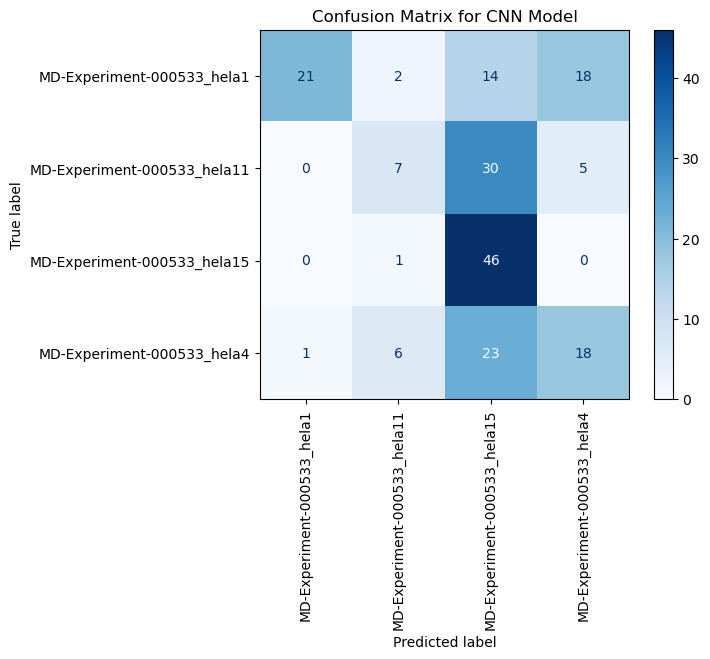

Confusion matrix saved as confusion_matrix.png


In [110]:
# Code Block 26
"""Saving confusion matrix as an image file"""

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues", xticks_rotation=90)

plt.title("Confusion Matrix for CNN Model")

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

print("Confusion matrix saved as confusion_matrix.png")

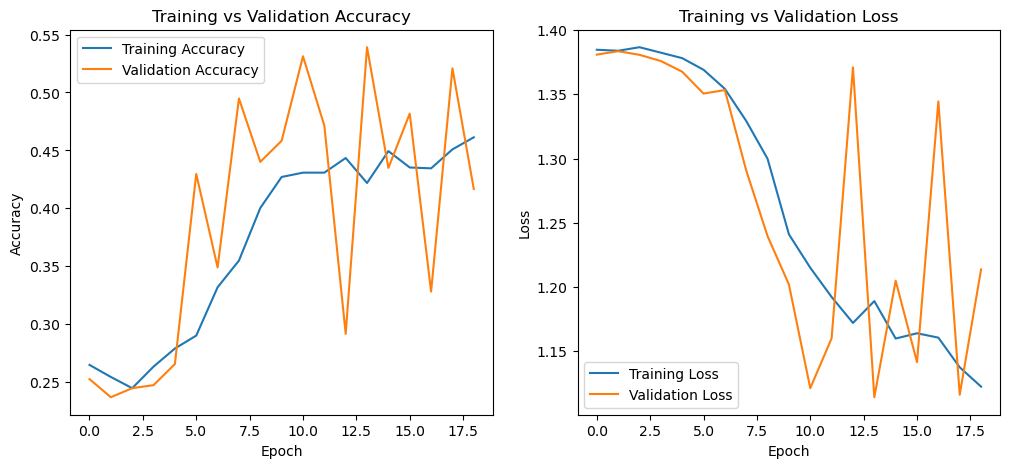

Training curves saved as training_curves.png


In [112]:
# Code Block 27
"""Saving training curves"""

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.savefig("training_curves.png", dpi=300, bbox_inches="tight")

plt.show()

print("Training curves saved as training_curves.png")

In [114]:
# Code Block 28
"""Saving model evaluation metrics to a CSV file"""

import pandas as pd
from sklearn.metrics import classification_report

report_dict = classification_report(
    y_true,
    y_predicted,
    target_names=class_names,
    output_dict=True
)

results_df = pd.DataFrame(report_dict).transpose()

results_df.to_csv("classification_results.csv")

print("Classification report saved as classification_results.csv")
results_df

Classification report saved as classification_results.csv


,precision,recall,f1-score,support
MD-Experiment-000533_hela1,0.954545,0.381818,0.545455,55.000000
MD-Experiment-000533_hela11,0.437500,0.166667,0.241379,42.000000
MD-Experiment-000533_hela15,0.407080,0.978723,0.575000,47.000000
MD-Experiment-000533_hela4,0.439024,0.375000,0.404494,48.000000
accuracy,0.479167,0.479167,0.479167,0.479167
macro avg,0.559537,0.475552,0.441582,192.000000
weighted avg,0.578546,0.479167,0.450931,192.000000


In [116]:
# Code Block 29

import numpy as np

for images, labels in train_ds.take(1):
    model.predict(images)

feature_extractor = keras.Model(
    inputs=model.inputs,
    outputs=model.layers[-3].output
)

X_train = []
y_train = []

for images, labels in train_ds:
    
    features = feature_extractor.predict(images, verbose=0)
    
    X_train.extend(features)
    y_train.extend(labels.numpy())

X_train = np.array(X_train)
y_train = np.array(y_train)

print("SVM train feature shape:", X_train.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


/opt/anaconda3/lib/python3.12/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_24']
Received: inputs=Tensor(shape=(32, 224, 224, 3))
  warnings.warn(msg)


SVM train feature shape: (1344, 64)


In [117]:
# Code Block 30

X_test = []
y_test = []

for images, labels in test_ds:
    
    features = feature_extractor.predict(images, verbose=0)
    
    X_test.extend(features)
    y_test.extend(labels.numpy())

X_test = np.array(X_test)
y_test = np.array(y_test)

print("SVM test feature shape:", X_test.shape)

SVM test feature shape: (192, 64)


2026-03-31 19:52:48.878346: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [120]:
# Code Block 31

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features standardized.")

Features standardized.


In [122]:
# Code Block 32

from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", C=1)

svm_model.fit(X_train_scaled, y_train)

print("SVM training completed.")

SVM training completed.


In [124]:
# Code Block 33

from sklearn.metrics import accuracy_score, classification_report

y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM Test Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report (SVM):")
print(classification_report(y_test, y_pred_svm, target_names=class_names))

SVM Test Accuracy: 0.859375

Classification Report (SVM):
                             precision    recall  f1-score   support

 MD-Experiment-000533_hela1       1.00      1.00      1.00        55
MD-Experiment-000533_hela11       0.92      0.76      0.83        46
MD-Experiment-000533_hela15       0.73      0.88      0.80        56
 MD-Experiment-000533_hela4       0.81      0.74      0.78        35

                   accuracy                           0.86       192
                  macro avg       0.87      0.84      0.85       192
               weighted avg       0.87      0.86      0.86       192



<Figure size 800x600 with 0 Axes>

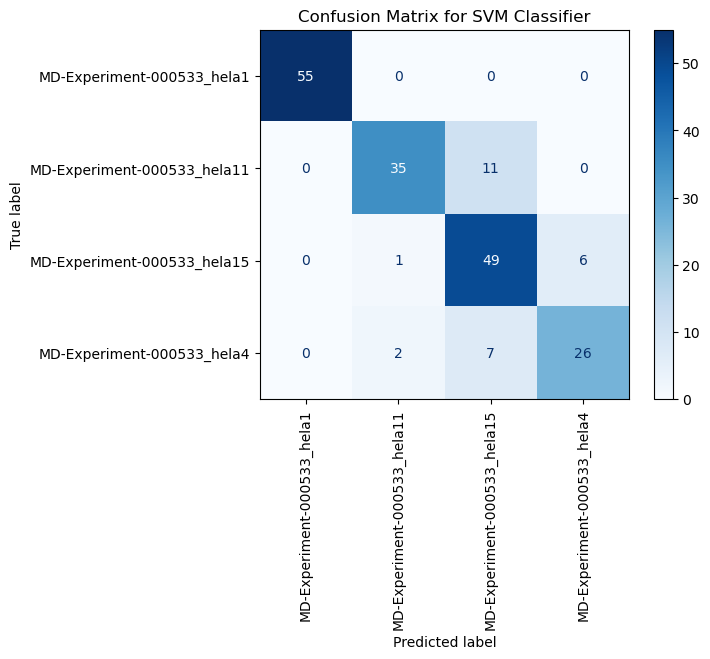

SVM confusion matrix saved as svm_confusion_matrix.png


In [128]:
# Code Block 34

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(8,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=class_names
)

disp.plot(cmap="Blues", xticks_rotation=90)

plt.title("Confusion Matrix for SVM Classifier")

plt.savefig("svm_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

print("SVM confusion matrix saved as svm_confusion_matrix.png")

In [130]:
# Code Block 35
"""Comparing CNN and SVM performance"""

import pandas as pd
from sklearn.metrics import accuracy_score

cnn_accuracy = test_accuracy

svm_accuracy = accuracy_score(y_test, y_pred_svm)

results = pd.DataFrame({
    "Model": ["CNN", "SVM (CNN Features)"],
    "Accuracy": [cnn_accuracy, svm_accuracy]
})

print("Model Performance Comparison:")
print(results)

results.to_csv("model_comparison.csv", index=False)

print("\nModel comparison saved as model_comparison.csv")

Model Performance Comparison:
                Model  Accuracy
0                 CNN  0.458333
1  SVM (CNN Features)  0.859375

Model comparison saved as model_comparison.csv
